# Set up

In [ ]:
from packaging import version
import numpy as np
import pandas as pd
import time
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds
from tensorflow.keras import layers
import tensorflow.keras.backend as k

import nltk
from nltk.corpus import stopwords

print("This notebook requires TensorFlow 2.0 or above")
print("TensorFlow version: ", tf.__version__)
assert version.parse(tf.__version__).release[0] >= 2


This notebook requires TensorFlow 2.0 or above
TensorFlow version:  2.19.0


In [ ]:
nltk.download('stopwords', quiet=True)
STOPWORDS = stopwords.words("english")

def custom_stopwords(input_text):
    lowercase = tf.strings.lower(input_text)
    stripped_punct = tf.strings.regex_replace(
        lowercase,
        '[%s]' % re.escape(string.punctuation),
        ''
    )
    return tf.strings.regex_replace(
        stripped_punct,
        r'\b(' + r'|'.join(STOPWORDS) + r')\b\s*',
        ""
    )


In [ ]:
dataset, info = tfds.load(
    'ag_news_subset',
    with_info=True,
    split=['train[:95%]', 'train[95%:]', 'test'],
    batch_size=32,
    as_supervised=True
)

train_ds, val_ds, test_ds = dataset
text_only_train_ds = train_ds.map(lambda x, y: x)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.6AQZM4_1.0.0/ag_news_subset-train.tfrecord*...: …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/ag_news_subset/incomplete.6AQZM4_1.0.0/ag_news_subset-test.tfrecord*...:  …

Dataset ag_news_subset downloaded and prepared to /root/tensorflow_datasets/ag_news_subset/1.0.0. Subsequent calls will reuse this data.


In [ ]:
max_length = 128
max_tokens = 5000

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length,
    standardize=custom_stopwords
)

text_vectorization.adapt(text_only_train_ds)

int_train_ds = train_ds.map(lambda x, y: (text_vectorization(x), y), num_parallel_calls=4)
int_val_ds   = val_ds.map(lambda x, y: (text_vectorization(x), y), num_parallel_calls=4)
int_test_ds  = test_ds.map(lambda x, y: (text_vectorization(x), y), num_parallel_calls=4)

#  speed
AUTOTUNE = tf.data.AUTOTUNE
int_train_ds = int_train_ds.cache().prefetch(AUTOTUNE)
int_val_ds   = int_val_ds.cache().prefetch(AUTOTUNE)
int_test_ds  = int_test_ds.cache().prefetch(AUTOTUNE)


# Experiment B (1)

In [ ]:
k.clear_session()

inputs = tf.keras.Input(shape=(None,), dtype="int64")

embedded = layers.Embedding(
    input_dim=max_tokens,
    output_dim=256,
    mask_zero=True
)(inputs)

x = layers.SimpleRNN(32)(embedded)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="rmsprop",
    loss="SparseCategoricalCrossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 32)        │      9,248 │ embedding[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        132 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,289,380 (4.92 MB)

 Trainable params: 1,289,380 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("B1_SimpleRNN.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

start_time = time.time()

history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=callbacks
)

training_time = time.time() - start_time
print("Training Time (seconds):", training_time)


Epoch 1/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 233s 65ms/step - accuracy: 0.7812 - loss: 0.6001 - val_accuracy: 0.8895 - val_loss: 0.3450
Epoch 2/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 213s 60ms/step - accuracy: 0.8890 - loss: 0.3614 - val_accuracy: 0.8900 - val_loss: 0.3435
Epoch 3/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 209s 59ms/step - accuracy: 0.9008 - loss: 0.3293 - val_accuracy: 0.8893 - val_loss: 0.3576
Epoch 4/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 209s 59ms/step - accuracy: 0.9091 - loss: 0.3046 - val_accuracy: 0.8853 - val_loss: 0.3663
Epoch 5/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 210s 59ms/step - accuracy: 0.9141 - loss: 0.2896 - val_accuracy: 0.8857 - val_loss: 0.3729
Training Time (seconds): 1074.8782804012299


In [ ]:
best_model = keras.models.load_model("B1_SimpleRNN.keras")
test_loss, test_acc = best_model.evaluate(int_test_ds)

print("\nB1 Test Accuracy:", test_acc)
print("B1 Test Loss:", test_loss)


238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8871 - loss: 0.3505

B1 Test Accuracy: 0.885921061038971
B1 Test Loss: 0.35376590490341187


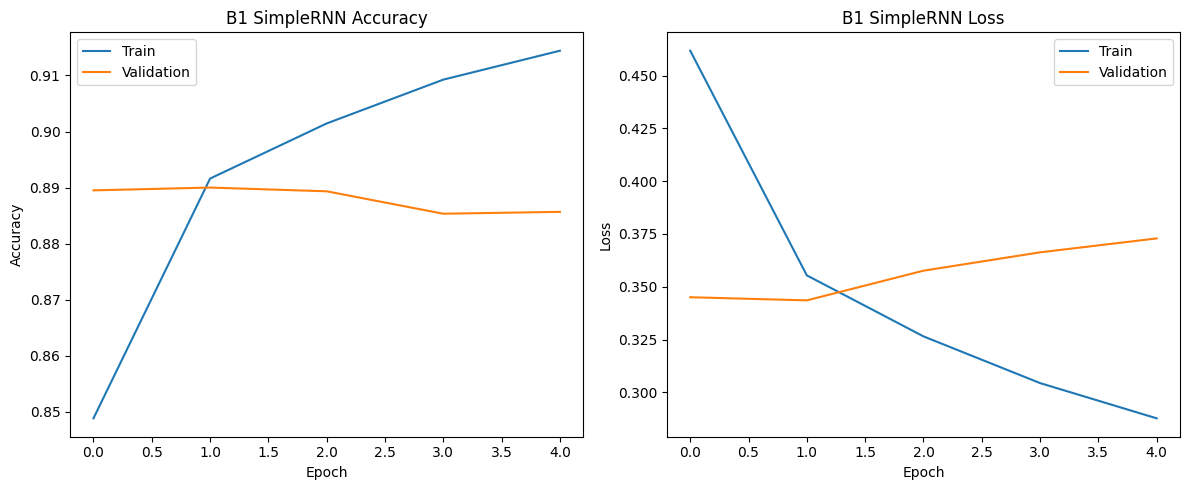

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('B1 SimpleRNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('B1 SimpleRNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(best_model.predict(int_test_ds), axis=-1)

print("Classification Report")
print(classification_report(y_test, pred_classes))

238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1900
           1       0.94      0.95      0.95      1900
           2       0.85      0.85      0.85      1900
           3       0.86      0.85      0.85      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



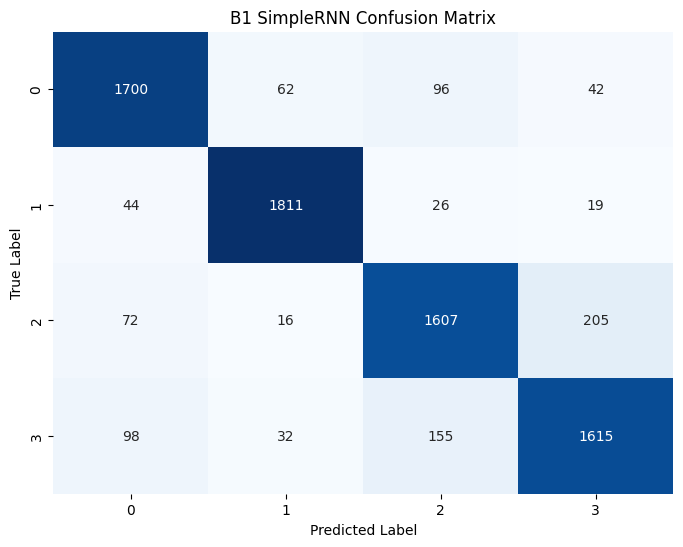

In [ ]:
mtx = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    mtx,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('B1 SimpleRNN Confusion Matrix')
plt.show()

# Experiment B (2)

In [ ]:

# Experiment B(2) — Bidirectional SimpleRNN


k.clear_session()

inputs = tf.keras.Input(shape=(None,), dtype="int64")

embedded = layers.Embedding(
    input_dim=max_tokens,
    output_dim=256,
    mask_zero=True
)(inputs)

x = layers.Bidirectional(layers.SimpleRNN(32))(embedded)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="rmsprop",
    loss="SparseCategoricalCrossentropy",
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("B2_BiSimpleRNN.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3)
]

start_time = time.time()

history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=callbacks
)

training_time = time.time() - start_time
print("Training Time (seconds):", training_time)

best_model = keras.models.load_model("B2_BiSimpleRNN.keras")
test_loss, test_acc = best_model.evaluate(int_test_ds)

print("\nB2 Test Accuracy:", test_acc)
print("B2 Test Loss:", test_loss)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 64)        │     18,496 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        260 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,298,756 (4.95 MB)

 Trainable params: 1,298,756 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 351s 98ms/step - accuracy: 0.8040 - loss: 0.5370 - val_accuracy: 0.8918 - val_loss: 0.3336
Epoch 2/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 395s 101ms/step - accuracy: 0.8976 - loss: 0.3142 - val_accuracy: 0.8913 - val_loss: 0.3333
Epoch 3/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 371s 98ms/step - accuracy: 0.9118 - loss: 0.2739 - val_accuracy: 0.8968 - val_loss: 0.3287
Epoch 4/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 345s 97ms/step - accuracy: 0.9228 - loss: 0.2419 - val_accuracy: 0.8925 - val_loss: 0.3445
Epoch 5/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 385s 98ms/step - accuracy: 0.9336 - loss: 0.2142 - val_accuracy: 0.8907 - val_loss: 0.3759
Epoch 6/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 342s 96ms/step - accuracy: 0.9411 - loss: 0.1887 - val_accuracy: 0.8887 - val_loss: 0.3949
Training Time (seconds): 2229.0271034240723
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8939 - loss: 0.3256

B2 Test Accuracy: 0.890657901763916
B2 Test Loss: 0.3360430598258972


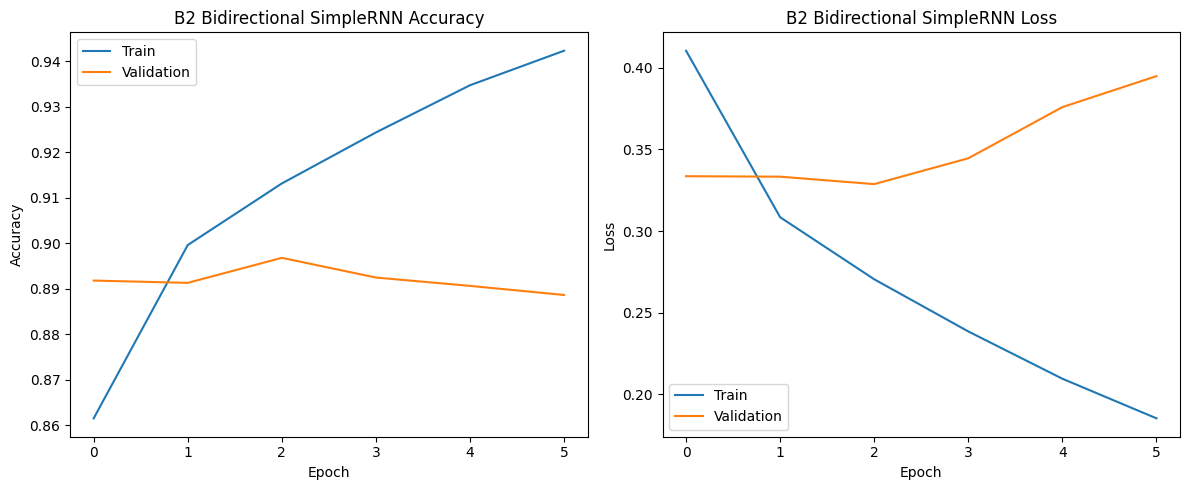

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_df['accuracy'])
plt.plot(history_df['val_accuracy'])
plt.title('B2 Bidirectional SimpleRNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history_df['loss'])
plt.plot(history_df['val_loss'])
plt.title('B2 Bidirectional SimpleRNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(best_model.predict(int_test_ds), axis=-1)

print("Classification Report")
print(classification_report(y_test, pred_classes))


238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step
Classification Report
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1900
           1       0.94      0.97      0.95      1900
           2       0.87      0.83      0.85      1900
           3       0.84      0.88      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



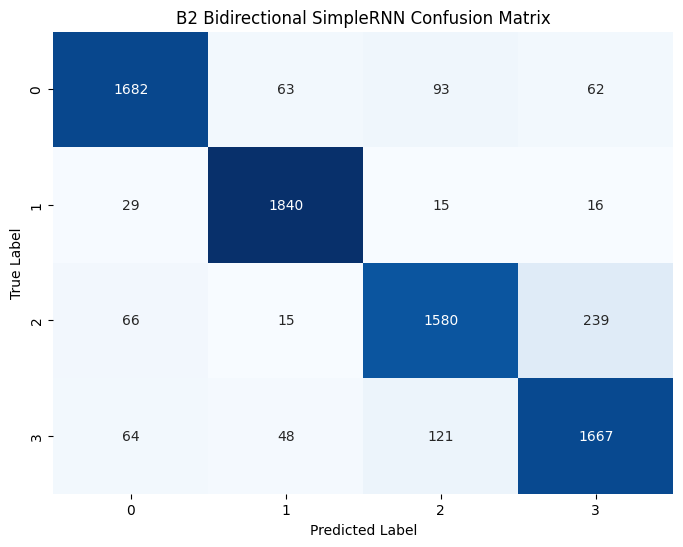

In [ ]:
mtx = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    mtx,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('B2 Bidirectional SimpleRNN Confusion Matrix')
plt.show()


# Experiment B (3) SimpleRNN (more units and less dropout)

In [ ]:
# Experiment B(3) — SimpleRNN (more units and less dropout)

k.clear_session()

inputs = tf.keras.Input(shape=(max_length,), dtype="int64")


try:
    vocab_size = len(text_vectorization.get_vocabulary())
except NameError:
    vocab_size = max_tokens

embedded = layers.Embedding(
    input_dim=vocab_size,
    output_dim=256,
    mask_zero=True
)(inputs)

x = layers.SimpleRNN(64)(embedded)     # changed 32 to 64
x = layers.Dropout(0.3)(x)            # changed 0.5 to 0.3

outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="B3_SimpleRNN_64u")
model.compile(
    optimizer="rmsprop",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("B3_SimpleRNN_64u.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3)
]

start_time = time.time()

history = model.fit(
    int_train_ds,
    validation_data=int_val_ds,
    epochs=10,
    callbacks=callbacks
)

training_time = time.time() - start_time
print("Training Time (seconds):", training_time)

best_model = keras.models.load_model("B3_SimpleRNN_64u.keras")
test_loss, test_acc = best_model.evaluate(int_test_ds)

print("\nB3 Test Accuracy:", test_acc)
print("B3 Test Loss:", test_loss)

Model: "B3_SimpleRNN_64u"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 128, 256)  │  1,280,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 128)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 64)        │     20,544 │ embedding[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        260 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,300,804 (4.96 MB)

 Trainable params: 1,300,804 (4.96 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 264s 73ms/step - accuracy: 0.7874 - loss: 0.5703 - val_accuracy: 0.8888 - val_loss: 0.3466
Epoch 2/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 242s 68ms/step - accuracy: 0.8895 - loss: 0.3457 - val_accuracy: 0.8917 - val_loss: 0.3540
Epoch 3/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 240s 67ms/step - accuracy: 0.9048 - loss: 0.3025 - val_accuracy: 0.8895 - val_loss: 0.3550
Epoch 4/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 239s 67ms/step - accuracy: 0.9156 - loss: 0.2700 - val_accuracy: 0.8847 - val_loss: 0.3767
Epoch 5/10
3563/3563 ━━━━━━━━━━━━━━━━━━━━ 242s 68ms/step - accuracy: 0.9238 - loss: 0.2449 - val_accuracy: 0.8845 - val_loss: 0.3906
Training Time (seconds): 1226.2263145446777
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8820 - loss: 0.3561

B3 Test Accuracy: 0.8802631497383118
B3 Test Loss: 0.3626956045627594


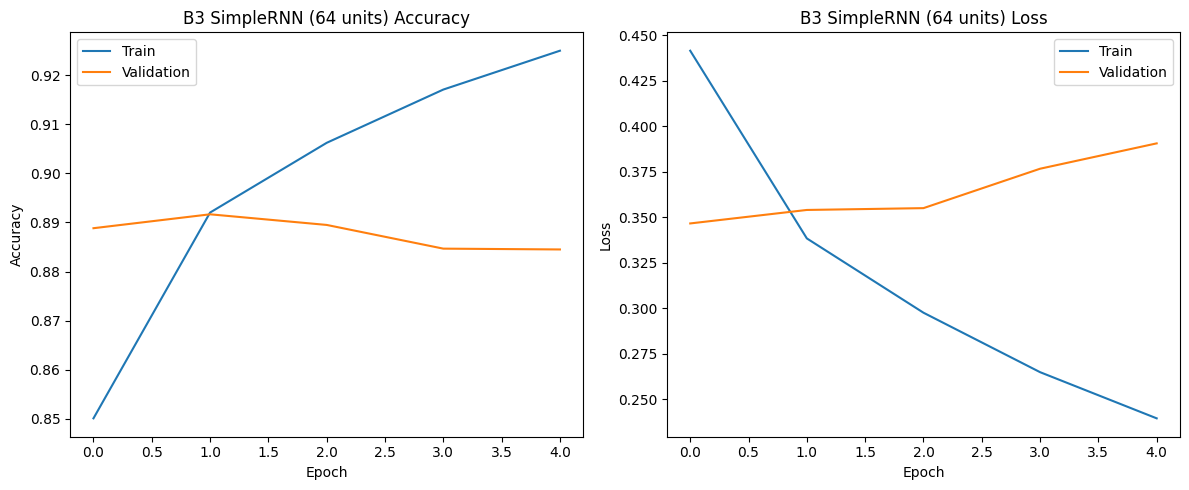

In [ ]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_df["accuracy"])
plt.plot(history_df["val_accuracy"])
plt.title("B3 SimpleRNN (64 units) Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history_df["loss"])
plt.plot(history_df["val_loss"])
plt.title("B3 SimpleRNN (64 units) Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.tight_layout()
plt.show()

238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step
              precision    recall  f1-score   support

           0       0.93      0.84      0.88      1900
           1       0.93      0.96      0.94      1900
           2       0.87      0.82      0.85      1900
           3       0.80      0.90      0.85      1900

    accuracy                           0.88      7600
   macro avg       0.88      0.88      0.88      7600
weighted avg       0.88      0.88      0.88      7600



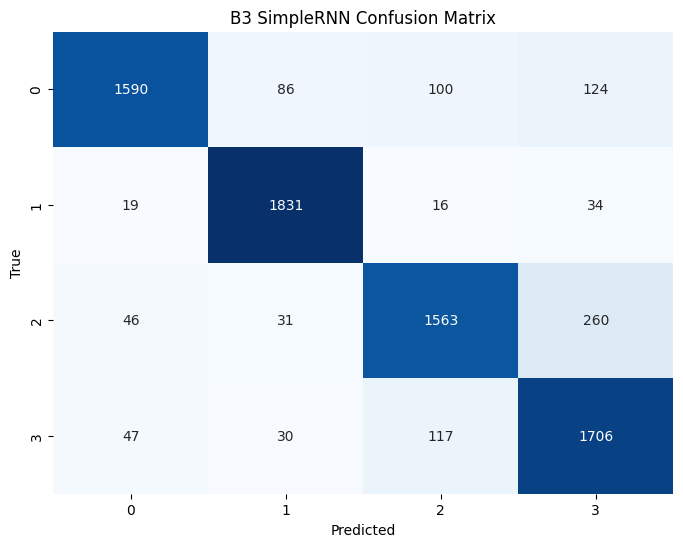

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_test = np.concatenate([y for x, y in int_test_ds], axis=0)
pred_classes = np.argmax(best_model.predict(int_test_ds), axis=-1)

print(classification_report(y_test, pred_classes))

mtx = confusion_matrix(y_test, pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(mtx, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("B3 SimpleRNN Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

### Experiment B3 — SimpleRNN (64 Units, Reduced Dropout)

This experiment evaluates the impact of increasing recurrent capacity and adjusting regularization in a unidirectional SimpleRNN.

Changes from B1:
- Increased hidden units from 32 → 64
- Reduced dropout from 0.5 → 0.3
- All other settings held constant (embedding size = 256, sequence length = 128, optimizer = RMSprop, loss = SparseCategoricalCrossentropy, same dataset splits)

Purpose:
To test whether increasing model capacity improves classification performance and to observe how regularization affects overfitting.

Results Summary:
- Training accuracy increased compared to B1.
- Validation accuracy remained relatively flat.
- Test accuracy (~0.885) did not improve over B1 (~0.886).
- Overfitting became more evident as training progressed.
- Bidirectional RNN (B2) still outperformed this larger unidirectional model.

Conclusion:
Increasing hidden units improved training fit but did not improve generalization performance. This suggests that model capacity alone does not guarantee better test accuracy and may increase overfitting without stronger regularization.